In [2]:
import pandas as pd 
import numpy as np
import time

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import(RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier)

from xgboost import XGBClassifier

from sklearn.metrics import (accuracy_score,precision_score,f1_score,recall_score,roc_auc_score,confusion_matrix,classification_report,RocCurveDisplay)

In [22]:
df=pd.read_csv("../dataset/churn_clean.csv")


In [23]:
df.drop("customerID",axis=1,inplace=True)

In [25]:
df["Churn"]=df["Churn"].map({"Yes":1,"No":0})

In [27]:
df=pd.get_dummies(df,drop_first=True)

In [29]:
# split the data now 

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [30]:
scaler = StandardScaler()

numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

X_train[numeric_features] = scaler.fit_transform(
    X_train[numeric_features]
)

X_test[numeric_features] = scaler.transform(
    X_test[numeric_features]
)

In [31]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
}

In [35]:
result=[]

for name,model in models.items():
    start=time.time()
    model.fit(X_train,y_train)
    training_time=time.time()-start

    prediction=model.predict(X_test)
    probability=model.predict_proba(X_test)[:,1]
    result.append({"model":name,
    "Accuracy":accuracy_score(y_test,prediction),
    "Precision":precision_score(y_test,prediction),
    "Recall":recall_score(y_test,prediction),
    "F1 Score":f1_score(y_test,prediction),
    "ROC AUC": roc_auc_score(y_test,prediction),
    "training time":training_time})


In [36]:
result_df=pd.DataFrame(result)

In [37]:
result_df.sort_values(by="Accuracy",ascending=False)

,model,Accuracy,Precision,Recall,F1 Score,ROC AUC,training time
2,AdaBoost,0.795309,0.648276,0.502674,0.566265,0.701966,0.382206
3,Gradient Boosting,0.795309,0.637821,0.532086,0.580175,0.711348,1.257233
1,Random Forest,0.788202,0.623377,0.513369,0.563050,0.700537,0.799207
4,XGBoost,0.771144,0.576023,0.526738,0.550279,0.693185,0.255811
0,Decision Tree,0.716418,0.466125,0.459893,0.462988,0.634593,0.060576


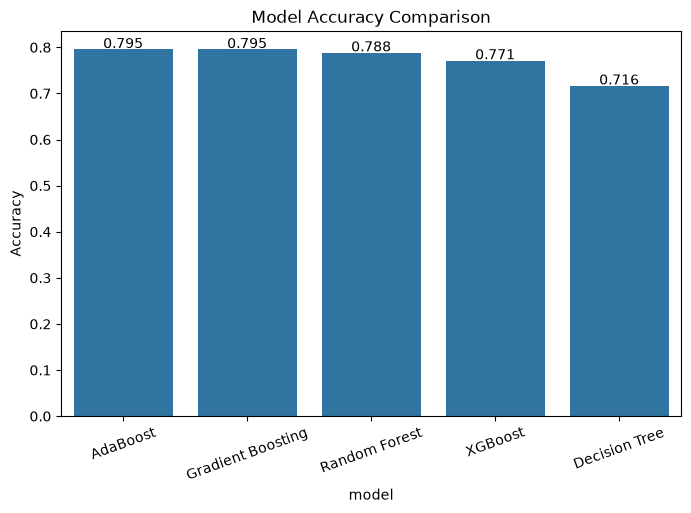

In [38]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=result_df.sort_values("Accuracy", ascending=False),
    x="model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.xticks(rotation=20)

for i, value in enumerate(result_df.sort_values("Accuracy", ascending=False)["Accuracy"]):
    plt.text(i, value + 0.003, f"{value:.3f}", ha="center")

plt.show()

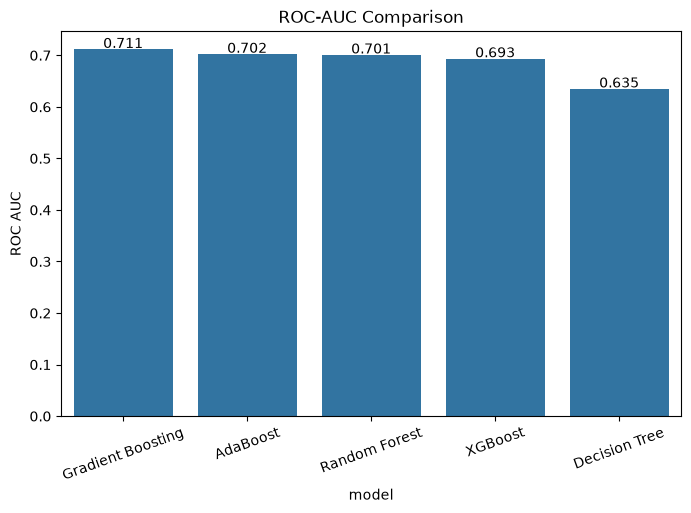

In [39]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=result_df.sort_values("ROC AUC", ascending=False),
    x="model",
    y="ROC AUC"
)

plt.title("ROC-AUC Comparison")
plt.xticks(rotation=20)

for i, value in enumerate(result_df.sort_values("ROC AUC", ascending=False)["ROC AUC"]):
    plt.text(i, value + 0.003, f"{value:.3f}", ha="center")

plt.show()

This shows that Gradient Boosting actually has the highest ROC-AUC, which is useful because ROC-AUC is often a better metric than accuracy for churn prediction